# FD_Kit: A Python library for Functional Diversity

A collection of Python functions and tools for exploring ecological and trait-based data. Includes functional diversity metrics like FRic, FEve, FDiv, FDis and RaoQ. Along with other useful functions for data preprocessing.

# Table of Contents
1. [Overview](#1.-Overview)
2. [Background](#2.-Background)
3. [Moving from R to Python](#3.-Moving-from-R-to-Python)
4. [Installation](#4.-Installation-and-Setup)
5. [Showcase of Functionality](#5.-Showcase-of-Functionality)
10. [References](#References)

# 1. Overview

In this notebook, we will explore what functional diversity is and the benefits of measuring it, as well as the difference between functional diversity and species diversity. We will also showcase the functionality of the FD_Kit library and how it can be used to calculate functional diversity metrics. These results will be compared to the R package `fundiversity` to validate the accuracy of the calculations.

# 2. Background 

### What is Functional Diversity?
Functional diversity is a quantifiable measure of species traits within a community. It provides insights into how species interact with each other and their environment, which can help us understand ecosystem functioning (Diaz and Cabido 2001).

As described by Villeger et al. (2008), functional diversity can be decomposed into three independent components: functional richness (FRic), functional evenness (FEve), and functional divergence (FDiv).

### Functional Diversity vs Species Diversity
While species diversity focuses on the number of species present in a community, functional diversity takes into account the traits of those species and how they contribute to ecosystem processes. 

# 3. Moving from R to Python

There are a number of R packages available for calculating functional diversity metrics such as `FD`, `mFD` with newer packages like `fundiversity` being developed to provide more optimized functions. However, there is a lack of Python packages available (and trustworthy) for calculating functional diversity metrics. And with the growing size of ecological datasets and use of Machine Learning in ecology, having a pipeline for calculating functional diversity metrics that seamlessly integrates with modern Python machine learning libraries is essential.

Modern machine learning libraries like `pytorch` and `tensorflow` are built and optimized for Python. Using a library like `rpy2` to make calls to R packages becomes inefficient due to parsing and data transfer processes. Therefore, having a Python library for calculating functional diversity metrics is essential.

# 4. Installation and Setup

1. Clone the repository from GitHub:
`
git clone https://github.com/qiulinlx/FD_kit
`

2. Navigate to the cloned directory:
`
cd FD_kit
`

3. Install the required dependencies (recommended to use a virtual environment):
`
pip install -r requirements.txt
`

### Optional: Run R code for validation
In order to run this notebook, you will need to have R installed on your system along with the `fundiversity` package. The `rpy2` library is used to run R code within the Python environment.

### Issues with loading `rpy2` in Jupyter Notebook



# 5. Showcase of functionality

## 5.1 Loading extensions and libraries

In [1]:
# Load extension for running R in Jupyter Notebook
%load_ext rpy2.ipython
# Load extension for autoreloading modules
%load_ext autoreload
%autoreload 2

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/envs/fd_library/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): symbol not found in flat namespace '_R_BaseEnv'")
Trying to import in ABI mode.


In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score

from utils import (
    functional_richness,
    functional_evenness,
    functional_divergence,
    functional_dispersion,
    raos_Q,
    compute_relative_abundance,
    standardize_trait_matrix,
    compute_distance_matrix,
)

## 5.2 Loading and exploring the data

The data used in this notebook is the same as the ones supplied in the `fundiversity` package. 

Birds:
- `bird_location.csv` contains the species abundance data for birds in different locations.
- `bird_traits.csv` contains the trait data for the bird species.

Plants:
- `plant_location.csv` contains the species abundance data for plants in different locations.
- `plant_traits.csv` contains the trait data for the plant species.

The location files contain presence-absence data for species in different plots, while the trait files contain the trait values for each species.

In [7]:
# Load the bird dataset
# Use the first column as the index column (Species names)
bird_traits = pd.read_csv("./data/example/bird/bird_traits.csv", index_col=0)
# Use the first column as the index column (Plot IDs)
bird_location = pd.read_csv("./data/example/bird/bird_location.csv", index_col=0)

# Load the plant dataset
# Use the first column as the index column (Species names)
plant_traits = pd.read_csv("./data/example/plant/plant_traits.csv", index_col=0)
# Use the first column as the index column (Plot IDs)
plant_location = pd.read_csv("./data/example/plant/plant_location.csv", index_col=0)

In [12]:
print("--- Bird dataset ---")
print(
    f"Bird traits shape: {bird_traits.shape[0]} species, {bird_traits.shape[1]} traits"
)
print(
    f"Bird location shape: {bird_location.shape[0]} plots, {bird_location.shape[1]} species"
)
print("--- Plant dataset ---")
print(
    f"Plant traits shape: {plant_traits.shape[0]} species, {plant_traits.shape[1]} traits"
)
print(
    f"Plant location shape: {plant_location.shape[0]} plots, {plant_location.shape[1]} species"
)

--- Bird dataset ---
Bird traits shape: 217 species, 4 traits
Bird location shape: 8 plots, 217 species
--- Plant dataset ---
Plant traits shape: 392 species, 4 traits
Plant location shape: 10 plots, 392 species


In [8]:
display(bird_traits.head())
display(bird_location.head())

,Bill.width..mm.,Bill.length..mm.,Kipp.s.index,Bodymass..g.
Species,,,,
Aburria_aburri,18.35,35.48,0.18,1407.5
Amazona_farinosa,26.50,38.81,0.29,626.0
Amazona_mercenaria,17.51,26.30,0.33,340.0
Amazona_ochrocephala,20.17,31.40,0.26,440.0
Ampelioides_tschudii,16.53,24.58,0.24,78.4


,Aburria_aburri,Amazona_farinosa,Amazona_mercenaria,Amazona_ochrocephala,Ampelioides_tschudii,Ampelion_rufaxilla,Andigena_hypoglauca,Anisognathus_igniventris,Anisognathus_somptuosus,Ara_ararauna,...,Turdus_ignobilis,Turdus_leucops,Turdus_nigriceps,Turdus_serranus,Tyrannus_savana,Tyrannus_tyrannus,Xenopipo_holochlora,Xenopipo_unicolor,Zimmerius_bolivianus,Zimmerius_gracilipes
PID,,,,,,,,,,,,,,,,,,,,,
elev_250,0,1,0,1,0,0,0,0,0,1,...,1,0,1,0,1,1,0,0,0,1
elev_500,0,1,0,1,0,0,0,0,0,1,...,1,0,1,0,1,1,1,0,0,1
elev_1000,1,1,1,0,1,0,0,0,0,1,...,1,1,1,0,0,0,1,1,1,0
elev_1500,1,0,1,0,0,0,1,0,1,0,...,1,1,1,1,0,0,0,1,1,0
elev_2000,0,0,1,0,0,1,1,0,1,0,...,0,1,0,1,0,0,0,0,1,0


## 5.3 Calculating functional diversity indices 

### 5.3.1 For the bird dataset (basic usage)

Basic usage of the functions implemented with no preprocessing of the data. Certain preprocessing steps can be specified as arguments to the functions. For example, if the traits are not standardized, the `standardize_traits_method` argument can be set to "z_score" or "min_max" to standardize the traits before calculating the functional diversity metrics.

In [120]:
# Compute functional richness (FRic) without standardizing the trait matrix
FRic_bird = functional_richness(
    sp_loc=bird_location, traits=bird_traits, standardize_traits_method=None
)

# Compute functional evenness (FEve) with abundance weighting and without standardizing the trait matrix
FEve_bird = functional_evenness(
    sp_loc=bird_location,
    traits=bird_traits,
    abundance_weighted=True,
    standardize_traits_method=None,
    distance_metric="euclidean",
)

# Compute functional divergence (FDiv) without standardizing the trait matrix
FDiv_bird = functional_divergence(
    sp_loc=bird_location,
    traits=bird_traits,
    calculate_relative_abundance=True,
    standardize_traits_method=None,
)

# Compute functional dispersion (FDis) with abundance weighting and without standardizing the trait matrix
FDis_bird = functional_dispersion(
    sp_loc=bird_location,
    traits=bird_traits,
    abundance_weighted=True,
    standardize_traits_method=None,
)

# Compute Rao's quadratic entropy (RaoQ) without standardizing the trait matrix
# The function can handle the calculation of the distance matrix if the traits have been provided and the distance metric is specified
RaoQ_bird = raos_Q(
    sp_loc=bird_location,
    traits=bird_traits,
    calculate_relative_abundance=True,
    standardize_traits_method=None,
    distance_metric="euclidean",
)

# Combine all functional diversity indices into a single DataFrame
FD_indices_bird_python = (
    FRic_bird.merge(FEve_bird, on="PID")
    .merge(FDiv_bird, on="PID")
    .merge(FDis_bird, on="PID")
    .merge(RaoQ_bird, on="PID")
)
display(FD_indices_bird_python)

,PID,Functional_Richness,Functional_Evenness,Functional_Divergence,Functional_Dispersion,Raos_Q
0,elev_250,171543.730477,0.384120,0.684725,151.388511,194.780954
1,elev_500,185612.547753,0.384619,0.693787,153.799819,197.081844
2,elev_1000,112600.176362,0.342669,0.705677,161.578158,200.522311
3,elev_1500,66142.747568,0.296558,0.726980,144.309148,178.248010
4,elev_2000,20065.764061,0.352399,0.750951,76.693855,97.324155
5,elev_2500,18301.176088,0.355267,0.698528,78.445772,102.224609
6,elev_3000,17530.650795,0.349253,0.662720,88.252012,113.220490
7,elev_3500,3708.734845,0.422244,0.642207,68.295630,87.047496


### 5.3.2 For the plant dataset (with preprocessing)

The functions also allow for preprocessed data to be used. For example, if the species abundance data is already in relative abundance format, the `calculate_relative_abundance` argument can be set to False to skip the calculation of relative abundances. Similarly, if the traits are already standardized, the `standardize_traits_method` argument can be set to None to skip the standardization step. For distance based metrics the distance matrix can be precomputed and passed to the functions to skip the distance calculation step.

In [121]:
# Calculate relative abundances for the plant dataset
relative_abundance_plant = compute_relative_abundance(plant_location)

# Standardize the trait matrix globally using z-score standardization
standardized_traits_plant = standardize_trait_matrix(plant_traits, method="z_score")

# Compute the distance matrix for the standardized trait matrix using Euclidean distance
distance_matrix_plant = compute_distance_matrix(
    standardized_traits_plant, metric="euclidean"
)

In [122]:
FRic_plant = functional_richness(
    sp_loc=relative_abundance_plant,
    traits=standardized_traits_plant,
    standardize_traits_method=None,
)

FEve_plant = functional_evenness(
    sp_loc=relative_abundance_plant,
    distance_matrix=distance_matrix_plant,
    abundance_weighted=True,
)

FDiv_plant = functional_divergence(
    sp_loc=relative_abundance_plant,
    traits=standardized_traits_plant,
    calculate_relative_abundance=False,
    standardize_traits_method=None,
)

FDis_plant = functional_dispersion(
    sp_loc=relative_abundance_plant,
    traits=standardized_traits_plant,
    abundance_weighted=True,
    standardize_traits_method=None,
)

RaoQ_plant = raos_Q(
    sp_loc=relative_abundance_plant,
    distance_matrix=distance_matrix_plant,
    calculate_relative_abundance=False,
)

FD_indices_plant_python = (
    FRic_plant.merge(FEve_plant, on="PID")
    .merge(FDiv_plant, on="PID")
    .merge(FDis_plant, on="PID")
    .merge(RaoQ_plant, on="PID")
)
display(FD_indices_plant_python)

,PID,Functional_Richness,Functional_Evenness,Functional_Divergence,Functional_Dispersion,Raos_Q
0,elev_250,475.126481,0.546239,0.713087,1.681203,2.383815
1,elev_500,478.365982,0.536450,0.730921,1.590812,2.252478
2,elev_1000,366.158153,0.521825,0.734072,1.402010,1.991427
3,elev_1500,323.597570,0.487882,0.743844,1.399372,1.996281
4,elev_2000,104.293838,0.501906,0.741463,1.136936,1.629624
5,elev_2500,22.170392,0.548015,0.736845,0.915752,1.312805
6,elev_3000,7.518166,0.566699,0.714491,0.791900,1.132302
7,elev_3500,1.935425,0.639661,0.716900,0.677649,0.957079
8,elev_3750,0.108074,0.719954,0.723694,0.626198,0.867243
9,elev_4000,NaN,NaN,NaN,NaN,NaN


### 5.3.3 Notes on usage

For each index there are two ways to calculate it. The first is to use the species abundance data and trait data directly, specifying the appropriate arguments for preprocessing. The second is to use preprocessed data, such as relative abundance data, standardized trait data and a precomputed distance matrix. This allows for more flexibility in how the functions can be used and can save time when working with large datasets by not doing the same computations repeatedly.

The datasets passed to the functions must be in the correct format. 

Species abundance data:
- Must be a pandas DataFrame.
- Rows as locations (Plot IDs).
- Columns as species.
- The plot IDs column must be set as the index of the DataFrame.

Species trait data
- Must be a pandas DataFrame 
- Rows as species 
- Columns as traits. 
- The species column must be set as the index of the DataFrame.

The distance matrix must be a square pandas DataFrame with rows and columns as species.

# 6. Comparison with R package `fundiversity`

To ensure the accuracy of the calculations, the results from the FD_Kit functions will be compared to the results from the R package `fundiversity`. The same datasets will be used for both calculations and the results will be compared to ensure that they are consistent.

In [123]:
FD_indices_bird_R = None
FD_indices_plant_R = None

In [124]:
%%R -i distance_matrix_plant -o FD_indices_bird_R,FD_indices_plant_R
# Load the R package `fundiversity`
library(fundiversity)

data(traits_birds)
data(site_sp_birds)

FRic_bird_R <- fundiversity::fd_fric(traits_birds, site_sp_birds)

FEve_bird_R <- fundiversity::fd_feve(traits_birds, site_sp_birds)

FDiv_bird_R <- fundiversity::fd_fdiv(traits_birds, site_sp_birds)

FDis_bird_R <- fundiversity::fd_fdis(traits_birds, site_sp_birds)

RaoQ_bird_R <- fundiversity::fd_raoq(traits_birds, site_sp_birds)

FD_indices_bird_R <- data.frame(
    PID  = FRic_bird_R$site,
    Functional_Richness = FRic_bird_R$FRic,
    Functional_Evenness = FEve_bird_R$FEve,
    Functional_Divergence = FDiv_bird_R$FDiv,
    Functional_Dispersion = FDis_bird_R$FDis,
    Raos_Q = RaoQ_bird_R$Q
)


data(traits_plants)
data(site_sp_plants)


# Because in the example above we standardized the traits before doing any calculation
# We will do the same here to ensure that the results are comparable
# The functions inside `fundiveristy` do not have the option to standardize the traits, so it must be done manually
traits_plant_cleaned <- traits_plants[rownames(traits_plants) %in% colnames(site_sp_plants), ]

traits_plants_standardized <- scale(traits_plants)

distance_matrix_plant <- as.matrix(distance_matrix_plant)

FRic_plant_R <- fundiversity::fd_fric(traits_plants_standardized, site_sp_plants)

FEve_plant_R <- fundiversity::fd_feve(traits_plants_standardized, site_sp_plants)

FDiv_plant_R <- fundiversity::fd_fdiv(traits_plants_standardized, site_sp_plants)

FDis_plant_R <- fundiversity::fd_fdis(traits_plants_standardized, site_sp_plants)

RaoQ_plant_R <- fundiversity::fd_raoq(traits_plants_standardized, site_sp_plants)

FD_indices_plant_R <- data.frame(
    PID  = FRic_plant_R$site,
    Functional_Richness = FRic_plant_R$FRic,
    Functional_Evenness = FEve_plant_R$FEve,
    Functional_Divergence = FDiv_plant_R$FDiv,
    Functional_Dispersion = FDis_plant_R$FDis,
    Raos_Q = RaoQ_plant_R$Q
)



In addition: Warning message:
In fundiversity::fd_fric(traits_plants_standardized, site_sp_plants) :
  Some sites had less species than traits so returned FRic is 'NA'


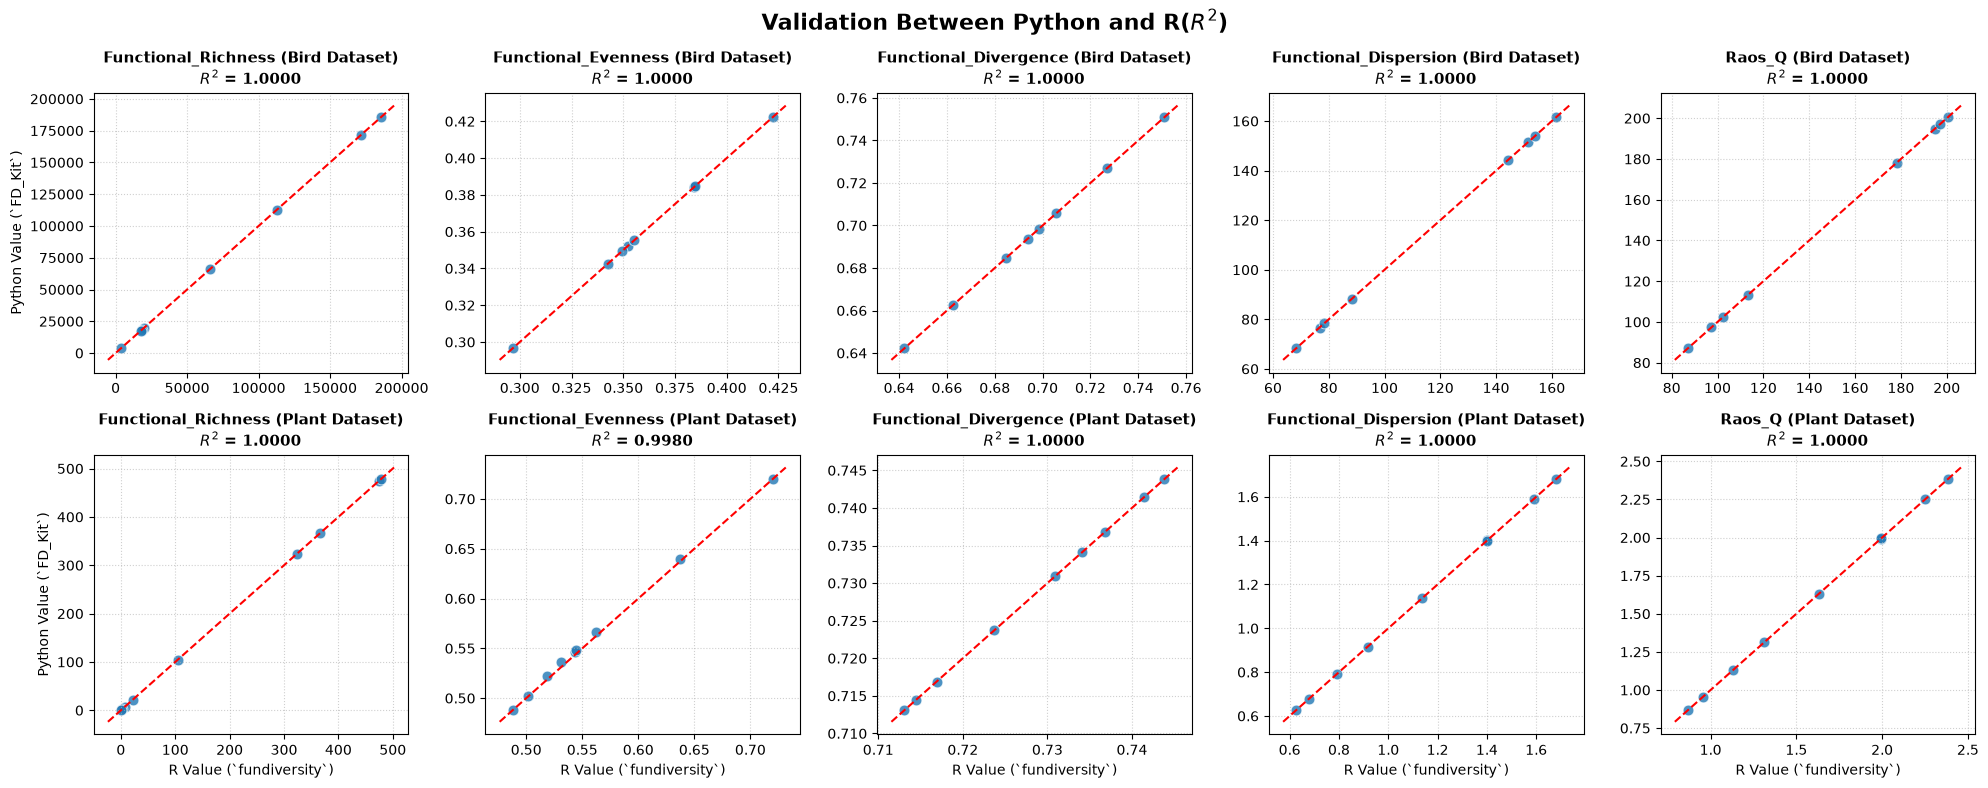

In [145]:
# List of metrics we want to compare
metrics = [
    "Functional_Richness",
    "Functional_Evenness",
    "Functional_Divergence",
    "Functional_Dispersion",
    "Raos_Q",
]

# Dictionary for datasets
datasets = {
    "Bird Dataset": {"R": FD_indices_bird_R, "Python": FD_indices_bird_python},
    "Plant Dataset": {"R": FD_indices_plant_R, "Python": FD_indices_plant_python},
}

# Set up a 2x5 plot (2 datasets, 5 metrics each)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=False, sharey=False)
fig.suptitle(
    "Validation Between Python and R($R^2$)", fontsize=16, fontweight="bold", y=0.98
)

# Loop through each dataset
for row_idx, (dataset_name, dfs) in enumerate(datasets.items()):
    # 1. Ensure dataframes are sorted identically by Plot ID (PID) so pairs line up perfectly
    df_r = dfs["R"].sort_values("PID").reset_index(drop=True)
    df_py = dfs["Python"].sort_values("PID").reset_index(drop=True)

    # Loop through each functional diversity metric
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        # Pull the values for R and Python
        temp_df = pd.DataFrame({"R": df_r[metric], "Python": df_py[metric]})

        temp_df = (
            temp_df.dropna()
        )  # Drop any rows with NaN values to ensure valid R² calculation
        y_r = temp_df["R"]
        y_py = temp_df["Python"]

        # Compute the R^2 score
        r2 = r2_score(y_r, y_py)

        # Create the scatter plot
        sns.scatterplot(
            x=y_r, y=y_py, ax=ax, color="#1f77b4", s=60, edgecolor="w", alpha=0.8
        )

        # Draw a y=x line to show alignment
        x_lim = ax.get_xlim()
        y_lim = ax.get_ylim()

        # Find the absolute minimum and maximum boundary across both axes to keep it perfectly square
        full_min = min(x_lim[0], y_lim[0])
        full_max = max(x_lim[1], y_lim[1])

        # Plot the line
        ax.plot(
            [full_min, full_max],
            [full_min, full_max],
            color="red",
            linestyle="--",
            linewidth=1.5,
            label="1:1 Line",
        )

        # Title and styling for individual subplot
        ax.set_title(
            f"{metric} ({dataset_name})\n$R^2$ = {r2:.4f}",
            fontsize=11,
            fontweight="semibold",
        )

        # Label axes nicely
        if row_idx == 1:
            ax.set_xlabel("R Value (`fundiversity`)", fontsize=10)
        else:
            ax.set_xlabel("")

        if col_idx == 0:
            ax.set_ylabel("Python Value (`FD_Kit`)", fontsize=10)
        else:
            ax.set_ylabel("")

        ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 10. References

Diaz, S., & Cabido, M. (2001). Vive la différence. Plant functional diversity matters to ecosystem processes. *Trends in Ecology & Evolution*, 16, 646-655.